In [78]:
import csv
import numpy as np
from typing import Set,Tuple, List
import torch
import torch.utils
import torch.utils.data
import torch.nn as nn
import torchvision
NoneType = type(None)
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from PIL import Image
import torchvision.transforms.functional as TF
from torchvision.models import vgg11
from torchvision.models import mobilenet_v2
import torchvision.transforms as transforms
import time


<h1 id="exercise-1"><strong>Exercise 1</strong></h1>


<font size="4px"><p>This method returns the fruit name by getting the string at a specific index of the set.</p>
<dl>
<dt>param fruit_id</dt>
<dd><p>The id of the fruit to get</p>
</dd>
<dt>param fruits</dt>
<dd><p>The set of fruits to choose the id from</p>
</dd>
<dt>return</dt>
<dd><p>The string corrosponding to the index <code>fruit_id</code></p>
</dd>
</dl>
<p><strong>This method is part of a series of debugging exercises.</strong> <strong>Each Python method of this series contains bug that needs to be found.</strong></p>
<div class="line-block"><code>1   It does not print the fruit at the correct index, why is the returned result wrong?</code><br />
<code>2   How could this be fixed?</code></div>
<p>This example demonstrates the issue: name1, name3 and name4 are expected to correspond to the strings at the indices 1, 3, and 4: 'orange', 'kiwi' and 'strawberry'..</p>
</font>

In [79]:
from typing import List

def id_to_fruit(fruit_id: int, fruits: List[str]) -> str:
    """
    This method returns the fruit name by getting the string at a specific index of the list.

    :param fruit_id: The id of the fruit to get
    :param fruits: The list of fruits to choose the id from
    :return: The string corresponding to the index ``fruit_id``
    """
    if 0 <= fruit_id < len(fruits):
        return fruits[fruit_id]
    raise RuntimeError(f"Fruit with id {fruit_id} does not exist")



In [80]:
# Example usage
fruits = ["apple", "orange", "melon", "kiwi", "strawberry"]  # Use a list to preserve order
print(f"Fruits ordering: {fruits}")

# Access by index
name1 = id_to_fruit(1, fruits)
name3 = id_to_fruit(3, fruits)
name4 = id_to_fruit(4, fruits)

print(name1)  # Should print "orange"
print(name3)  # Should print "kiwi"
print(name4)  # Should print "strawberry"


Fruits ordering: ['apple', 'orange', 'melon', 'kiwi', 'strawberry']
orange
kiwi
strawberry


<h1 id="Answers"><strong>Answers</strong></h1>

<font size="4px"><p>Questions</p></font>
<b>1. It does not print the fruit at the correct index, why is the returned result wrong? </b></br>
</br>
Answer. The issue lies in the use of a set for the fruits parameter. Python set objects are unordered collections, meaning the order of elements is not guaranteed. When iterating through a set, the elements appear in an arbitrary order based on their internal hashing, which causes the index-based access to fail.

In the original code:
    

The fruit variable is retrieved in an arbitrary order, so the fruit_id does not reliably correspond to the intended index.

<b>2. How could this be fixed? </b></br>
</br>
To fix the issue, replace the <b>set</b> with a <b>list</b>. Lists maintain a predictable, sequential order, allowing index-based access. The corrected implementation would look like this:

If maintaining the use of <b>set</b> is essential, you must convert it to a <b>list</b> in a predictable manner (e.g., via <b>sorted(fruits)</b> or by explicitly defining a desired order). However, the preferred solution is to use a <b>list</b> in scenarios where order matters, as lists are inherently ordered.

<b>-------------------------------------------------------------------------------------------------------------------------------</b>

<h1 id="exercise-2"><strong>Exercise 2</strong></h1>


<font size="4px"><p>This method will flip the x and y coordinates in the coords array.</p>
<dl>
<dt>param coords</dt>
<dd><p>A numpy array of bounding box coordinates with shape [n,5] in format: :</p>
<pre><code>[[x11, y11, x12, y12, classid1],
 [x21, y21, x22, y22, classid2],
 ...
 [xn1, yn1, xn2, yn2, classid3]]</code></pre>
</dd>
<dt>return</dt>
<dd><p>The new numpy array where the x and y coordinates are flipped.</p>
</dd>
</dl>
<p><strong>This method is part of a series of debugging exercises.</strong> <strong>Each Python method of this series contains bug that needs to be found.</strong></p>
<div class="line-block"><code>1   Can you spot the obvious error?</code><br />
<code>2   After fixing the obvious error it is still wrong, how can this be fixed?</code></div>
</font>

<font size="4px"><p>The example demonstrates the issue. The returned swapped_coords are expected to have swapped x and y coordinates in each of the rows.</p>
</font>

In [81]:
def swap(coords: np.ndarray) -> np.ndarray:
    """
    This method will flip the x and y coordinates in the coords array.

    :param coords: A numpy array of bounding box coordinates with shape [n,5]
    :return: The new numpy array where the x and y coordinates are flipped.
    """
    # Create a copy to avoid modifying the input array
    swapped_coords = coords.copy()
    # Perform the swap on the copied array
    swapped_coords[:, 0] = coords[:, 1]  
    swapped_coords[:, 1] = coords[:, 0]
    swapped_coords[:, 2] = coords[:, 3]
    swapped_coords[:, 3] = coords[:, 2]
#     x1, y1, x2, y2 = swapped_coords[:, 0], swapped_coords[:, 1], swapped_coords[:, 2], swapped_coords[:, 3]
#     swapped_coords[:, 0], swapped_coords[:, 1], swapped_coords[:, 2], swapped_coords[:, 3] = y1, x1, y2, x2
    return swapped_coords

In [82]:
import numpy as np

coords = np.array([[10, 5, 15, 6, 0],
                   [11, 3, 13, 6, 0],
                   [5, 3, 13, 6, 1],
                   [4, 4, 13, 6, 1],
                   [6, 5, 13, 16, 1]])

swapped_coords = swap(coords)

print("Original coords:")
print(coords)
print("\nSwapped coords:")
print(swapped_coords)


Original coords:
[[10  5 15  6  0]
 [11  3 13  6  0]
 [ 5  3 13  6  1]
 [ 4  4 13  6  1]
 [ 6  5 13 16  1]]

Swapped coords:
[[ 5 10  6 15  0]
 [ 3 11  6 13  0]
 [ 3  5  6 13  1]
 [ 4  4  6 13  1]
 [ 5  6 16 13  1]]


<h1 id="Answers"><strong>Answers</strong></h1>

<font size="4px"><p>Questions</p></font>
<b>1. Can you spot the obvious error? </b></br>
</br>

The obvious error is in this line of the original implementation:

The problem:
</br>
1. In-place overwriting of columns: The <b>coords[:, 0]</b> and <b>coords[:, 1]</b> assignments overwrite each other because they depend on values from <b>coords[:, 1]</b>. This leads to incorrect values for the x-coordinates after the first assignment. </br>
2. This same issue applies to <b>coords[:, 2]</b> and <b>coords[:, 3]</b>, which also overwrite each other due to dependencies.
</br>
</br>
For example, after the first assignment <b>coords[:, 0] = coords[:, 1]</b>, the original value of <b>coords[:, 0]</b> is lost, which affects the next assignment.

<b>2. After fixing the obvious error it is still wrong, how can this be fixed?</b></br>
</br>
After fixing the overwriting issue, the method still modifies the input coords array directly, which can lead to unintended side effects. To ensure correctness and avoid modifying the input, the following steps should be taken:

1. Copy the input array: Create a new array to store the swapped coordinates, leaving the original array unmodified.

2. Swap the coordinates on the copied array: Correctly swap the x and y coordinates by reassigning them without overwriting:

3. Return the swapped array: Return the new array without modifying the original.

<h1 id="exercise-3"><strong>Exercise 3</strong></h1>


<font size="4px"><p>This code plots the precision-recall curve based on data from a .csv file, where precision is on the x-axis and recall is on the y-axis. It it not so important right now what precision and recall means.</p>
<dl>
<dt>param csv_file_path</dt>
<dd><p>The CSV file containing the data to plot.</p>
</dd>
</dl>
<p><strong>This method is part of a series of debugging exercises.</strong> <strong>Each Python method of this series contains bug that needs to be found.</strong></p>
<div class="line-block"><code>1   For some reason the plot is not showing correctly, can you find out what is going wrong?</code><br />
<code>2   How could this be fixed?</code></div>
<p>This example demonstrates the issue. It first generates some data in a csv file format and the plots it using the <code>plot_data</code> method. If you manually check the coordinates and then check the plot, they do not correspond.</p>
</font>

In [83]:
import csv
import numpy as np
import matplotlib.pyplot as plt

def plot_data(csv_file_path: str):
    """
    This code plots the precision-recall curve based on data from a .csv file,
    where precision is on the x-axis and recall is on the y-axis.

    :param csv_file_path: The CSV file containing the data to plot.
    """
    # Use np.loadtxt to load data directly and skip the header
    results = np.loadtxt(csv_file_path, delimiter=',', skiprows=1)

    # Validate the shape of the data
    if results.shape[1] != 2:
        raise ValueError("Data file must contain exactly two columns: 'precision' and 'recall'.")

    # Plot precision-recall curve
    plt.plot(results[:, 0], results[:, 1], marker='o')  # Add markers for better visualization
    plt.ylim([-0.05, 1.05])
    plt.xlim([-0.05, 1.05])
    plt.xlabel('Precision')  # x-axis label
    plt.ylabel('Recall')     # y-axis label
    plt.title('Precision-Recall Curve')  # Add a title for clarity
    plt.grid(True)  # Optional: add grid for better readability
    plt.show()



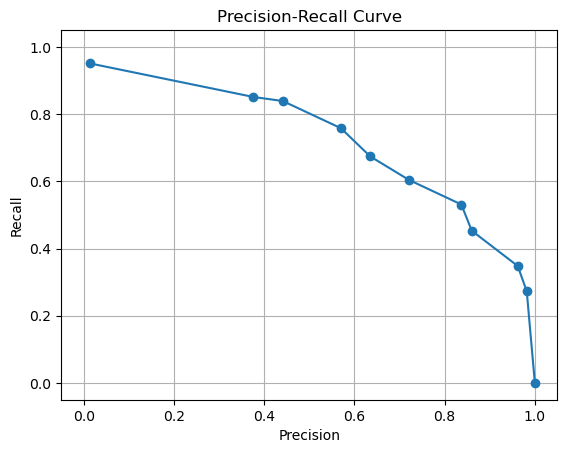

In [84]:
# Writing the data to a CSV file
f = open("data_file.csv", "w")
w = csv.writer(f)
_ = w.writerow(["precision", "recall"])
w.writerows([[0.013, 0.951],
             [0.376, 0.851],
             [0.441, 0.839],
             [0.570, 0.758],
             [0.635, 0.674],
             [0.721, 0.604],
             [0.837, 0.531],
             [0.860, 0.453],
             [0.962, 0.348],
             [0.982, 0.273],
             [1.0, 0.0]])
f.close()

# Plotting the data
plot_data('data_file.csv')



<h1 id="Answers"><strong>Answers</strong></h1>

<font size="4px"><p>Questions</p></font>
<b>1. For some reason the plot is not showing correctly, can you find out what is going wrong? </b></br>
</br>
The issue lies in how the data is read and stored in the results array:

The problem:</br>
1. Data type issue during <b>csv.reader</b> iteration: <b>csv.reader</b> reads each value as a string. However, when appending rows, they remain as lists of strings until converted using <b>np.array(results, dtype=float)</b>. This conversion works for the numeric data but fails to reshape the results into the expected 2D array if any row contains incorrect formatting. </br></br>
2. Misalignment between columns: If the CSV data is not read correctly or if the rows are incorrectly structured, the slicing <b>results[:, 0]</b> and <b>results[:, 1]</b> will either fail or produce unintended data.

<b>2. How could this be fixed? </b></br>
</br>

To fix these issues, the data parsing process and the subsequent plotting logic must be corrected: </br>
1. Ensure the data is properly loaded and converted to a numpy array: </br>                                                   Use np.loadtxt with the appropriate delimiter to load the CSV file directly into a 2D numpy array.</br>
Skip the header row during loading.
2. Verify the data format after loading: Before plotting, check that the data array has the expected dimensions <b>([n, 2])</b> and that all values are numeric.

<font size="4px"><b><p>Corrected Code and Explanation</p></b></font></br>
<font size="3px"><b>Loading the Data:</b></font></br>
Using <b>np.loadtxt</b> simplifies the CSV reading process and ensures data is loaded as a clean numpy array:

<font size="3px"><b>Shape Validation:</b></font></br>
Check the array's shape to ensure it contains two columns (precision and recall). This avoids slicing errors:

<font size="3px"><b>What Changed?</b></font></br></br>
1. Replaced manual CSV parsing with <b>np.loadtxt</b> for robust and efficient data loading.</br>
2. Validated the data structure before plotting to prevent slicing errors.</br>
3. Improved the plot's readability with markers, grid lines, and a title.

<h1 id="generator-for-exercise-4">** Generator (for Exercise 4)**</h1>


<font size="4px"><p>Generator class for the GAN</p>
</font>

In [90]:
# You can copy this code to your personal pipeline project or execute it here.
class Generator(nn.Module):
    """
    Generator class for the GAN
    """

    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 784),
            nn.Tanh(),
        )

    def forward(self, x):
        output = self.model(x)
        output = output.view(x.size(0), 1, 28, 28)
        return output



<h1 id="discriminator-for-exercise-4">** Discriminator (for Exercise 4)**</h1>


<font size="4px"><p>Discriminator class for the GAN</p>
</font>

In [91]:
# You can copy this code to your personal pipeline project or execute it here.
class Discriminator(nn.Module):
    """
    Discriminator class for the GAN
    """
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.view(x.size(0), 784)
        output = self.model(x)
        return output



<h1 id="exercise-4">** Exercise 4**</h1>


<font size="4px"><p>The method trains a Generative Adversarial Network and is based on: <a href="https://realpython.com/generative-adversarial-networks/">https://realpython.com/generative-adversarial-networks/</a></p>
<p>The Generator network tries to generate convincing images of handwritten digits. The Discriminator needs to detect if the image was created by the Generater or if the image is a real image from a known dataset (MNIST). If both the Generator and the Discriminator are optimized, the Generator is able to create images that are difficult to distinguish from real images. This is goal of a GAN.</p>
<p>This code produces the expected results at first attempt at about 50 epochs.</p>
<dl>
<dt>param batch_size</dt>
<dd><p>The number of images to train in one epoch.</p>
</dd>
<dt>param num_epochs</dt>
<dd><p>The number of epochs to train the gan.</p>
</dd>
<dt>param device</dt>
<dd><p>The computing device to use. If CUDA is installed and working then <span class="title-ref">cuda:0</span> is chosen otherwise 'cpu' is chosen. Note: Training a GAN on the CPU is very slow.</p>
</dd>
</dl>
<p><strong>This method is part of a series of debugging exercises.</strong> <strong>Each Python method of this series contains bug that needs to be found.</strong></p>
<p>It contains at least two bugs: one structural bug and one cosmetic bug. Both bugs are from the original tutorial.</p>
<div class="line-block"><code>1   Changing the batch_size from 32 to 64 triggers the structural bug.</code><br />
<code>2   Can you also spot the cosmetic bug?</code><br />
<code>Note: to fix this bug a thorough understanding of GANs is not necessary.</code></div>
<p>Change the batch size to 64 to trigger the bug with message: ValueError: "Using a target size (torch.Size([128, 1])) that is different to the input size (torch.Size([96, 1])) is deprecated. Please ensure they have the same size."</p>
</font>

In [94]:
# Training the GAN
def train_gan(batch_size: int = 32, num_epochs: int = 100, device: str = "cuda:0" if torch.cuda.is_available() else "cpu"):
    """
    The method trains a Generative Adversarial Network (GAN) using MNIST dataset.
    The Generator generates images, and the Discriminator distinguishes between real and generated images.
    
    :param batch_size: The number of images to train in one epoch.
    :param num_epochs: The number of epochs to train the GAN.
    :param device: The computing device to use, either 'cpu' or 'cuda:0'.
    """

    # Transformation for the MNIST dataset
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

    try:
        train_set = torchvision.datasets.MNIST(root=".", train=True, download=True, transform=transform)
    except:
        print("Failed to download MNIST, retrying with a different URL")
        torchvision.datasets.MNIST.resources = [
            ('https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz',
             'f68b3c2dcbeaaa9fbdd348bbdeb94873'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz',
             'd53e105ee54ea40749a09fcbcd1e9432'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz',
             '9fb629c4189551a2d022fa330f9573f3'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz',
             'ec29112dd5afa0611ce80d1b7f02629c')
        ]
        train_set = torchvision.datasets.MNIST(root=".", train=True, download=True, transform=transform)

    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)

    # Example data
    real_samples, mnist_labels = next(iter(train_loader))

    fig = plt.figure()
    for i in range(16):
        sub = fig.add_subplot(4, 4, 1 + i)
        sub.imshow(real_samples[i].reshape(28, 28), cmap="gray_r")
        sub.axis('off')

    fig.tight_layout()
    fig.suptitle("Real images")
    display(fig)

    time.sleep(5)

    # Set up training
    discriminator = Discriminator().to(device)
    generator = Generator().to(device)
    lr = 0.0001
    loss_function = nn.BCELoss()
    optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
    optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

    # Training loop
    for epoch in range(num_epochs):
        for n, (real_samples, mnist_labels) in enumerate(train_loader):

            # Data for training the discriminator
            real_samples = real_samples.to(device=device)
            real_samples_labels = torch.ones((batch_size, 1)).to(device=device)
            latent_space_samples = torch.randn((batch_size, 100)).to(device=device)
            generated_samples = generator(latent_space_samples)
            generated_samples_labels = torch.zeros((batch_size, 1)).to(device=device)
            all_samples = torch.cat((real_samples.view(batch_size, -1), generated_samples.view(batch_size, -1)))
            all_samples_labels = torch.cat((real_samples_labels, generated_samples_labels))

            # Training the discriminator
            discriminator.zero_grad()
            output_discriminator = discriminator(all_samples)
            loss_discriminator = loss_function(output_discriminator, all_samples_labels)
            loss_discriminator.backward()
            optimizer_discriminator.step()

            # Data for training the generator
            latent_space_samples = torch.randn((batch_size, 100)).to(device=device)

            # Training the generator
            generator.zero_grad()
            generated_samples = generator(latent_space_samples)
            output_discriminator_generated = discriminator(generated_samples)
            loss_generator = loss_function(output_discriminator_generated, real_samples_labels)
            loss_generator.backward()
            optimizer_generator.step()

            # Show loss and generated samples
            if n == batch_size - 1:
                name = f"Generate images\n Epoch: {epoch} Loss D.: {loss_discriminator:.2f} Loss G.: {loss_generator:.2f}"
                generated_samples = generated_samples.detach().cpu().numpy()
                fig = plt.figure()
                for i in range(16):
                    sub = fig.add_subplot(4, 4, 1 + i)
                    sub.imshow(generated_samples[i].reshape(28, 28), cmap="gray_r")
                    sub.axis('off')
                fig.suptitle(name)
                fig.tight_layout()
                clear_output(wait=False)
                display(fig)

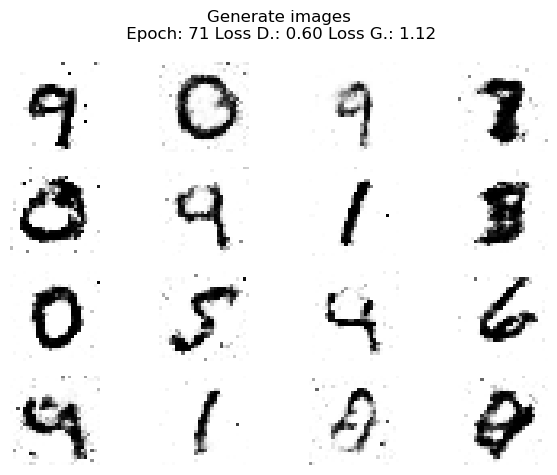

In [ ]:
# Call the function to train the GAN
train_gan(batch_size=32, num_epochs=100)

<h1 id="Answers"><strong>Answers</strong></h1></br>
<b>1. Changing the batch_size from 32 to 64 triggers the structural bug.</b></br></br>
The structural bug occurs because the real_samples and generated_samples are treated as tensors with different shapes. When the batch size is changed to 64, the dimensions of the tensors don't align, causing a mismatch in their sizes during concatenation for the Discriminator's input.</br>
Specifically:</br>
1. The <b>real_samples</b> tensor has the shape <b>(batch_size, 1, 28, 28)</b>, but when flattened with <b>.view(batch_size, -1)</b>, it turns into <b>(batch_size, 784)</b>.</br>
2. The <b>generated_samples</b> tensor has the same shape when flattened, but when concatenated, the batch size mismatch causes a problem. This bug occurs because the model expects consistent batch sizes for both real and generated samples, and changing the batch size without properly adjusting the model could lead to mismatches.</br>

Fix: The concatenation operation needs to ensure that both <b>real_samples</b> and <b>generated_samples</b> are flattened in the same way and have the same batch size.</br>

<b>2. Can you also spot the cosmetic bug?</b></br></br>
The cosmetic bug in this code is related to how the images are displayed. In the original tutorial, the real images were shown for 5 seconds using <b>time.sleep(5)</b> before displaying the generated images. This could potentially make the display look static, and the real images were not being cleared or updated in the notebook, which can lead to confusion.</br>
Fix: While this doesn't directly affect the functionality, the visual display can be improved by removing the time.sleep(5) call and ensuring that the images are updated in real time as the training progresses. The <b>clear_output(wait=False)</b> command is used to clear the previous output to make room for new generated images. This ensures the user sees the latest results during training without delay.